# Region exploration

Pick a `region_id` and look at how its climate and drought score evolve across the train and test windows.

Two main entry points:
- `explore_region('R1')` — printed summary, drought table, and a stack of plots
- `table_view('R1')` — interactive raw-data table with a column picker

Note on dates: the dataset uses a synthetic calendar (year fields go up to ~58,061 and every 4th year is a leap year on an offset), so we can't parse them with Python's `datetime`. Instead we build a monotonic `day_idx = year*372 + (month-1)*31 + (day-1)` for sorting and positioning on plots. Differences in `day_idx` approximate days within a few percent.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display

DATA = Path('data')

## Load data

`train.csv` is ~1 GB so the first load takes a moment.

In [43]:
train = pd.read_csv(DATA / 'train.csv')
test  = pd.read_csv(DATA / 'test.csv')

print(f'Train: {len(train):,} rows, {train.region_id.nunique()} regions')
print(f'Test:  {len(test):,} rows, {test.region_id.nunique()} regions')
print(f'Example region IDs: {sorted(train.region_id.unique())[:10]}')

Train: 12,319,040 rows, 2248 regions
Test:  204,568 rows, 2248 regions
Example region IDs: ['R1', 'R1001', 'R1002', 'R1005', 'R1006', 'R1007', 'R1009', 'R1011', 'R1012', 'R1014']


## Per-region helpers

- `get_region(region_id)` → merged train+test DataFrame sorted in time, with `split` and `day_idx` columns
- `drought_periods(df, threshold)` → table of contiguous runs where `score >= threshold`

In [44]:
def get_region(region_id):
    tr = train[train.region_id == region_id].copy()
    te = test[test.region_id == region_id].copy()
    tr['split'] = 'train'
    te['split'] = 'test'
    df = pd.concat([tr, te], ignore_index=True)
    ymd = df['date'].str.split('-', expand=True).astype(int)
    df['day_idx'] = ymd[0] * 372 + (ymd[1] - 1) * 31 + (ymd[2] - 1)
    return df.sort_values('day_idx').reset_index(drop=True)


def drought_periods(df, threshold=1):
    # Score is reported weekly, so filter to rows that actually carry a
    # score and detect runs over those weekly observations.
    w = df[df['score'].notna()].reset_index(drop=True)
    in_drought = w['score'] >= threshold
    runs = (in_drought != in_drought.shift()).cumsum()
    out = w.loc[in_drought].groupby(runs[in_drought]).agg(
        start=('date', 'min'),
        end=('date', 'max'),
        weeks=('date', 'count'),
        max_score=('score', 'max'),
        mean_score=('score', 'mean'),
    ).reset_index(drop=True)
    out['days_approx'] = out['weeks'] * 7
    return out

## Plots

Four stacked panels share the x-axis: drought score (droughts shaded red), temperature (min–max band + mean), precipitation, humidity. The train→test gap is the grey vertical band; its real width on the x-axis is preserved by using `day_idx` as the coordinate.

In [45]:
def _weekly_sum(part, col):
    # Sum every 7 consecutive daily rows within a split (train or test).
    p = part.reset_index(drop=True).copy()
    p['_w'] = p.index // 7
    return p.groupby('_w').agg(day_idx=('day_idx', 'mean'), value=(col, 'sum'))


def plot_region(region_id, drought_threshold=1):
    df = get_region(region_id)
    x  = df['day_idx'].values
    tr = df[df.split == 'train']
    te = df[df.split == 'test']
    train_end_x   = tr['day_idx'].max()
    test_start_x  = te['day_idx'].min()
    train_end_str = tr['date'].iloc[-1]
    test_start_str= te['date'].iloc[0]
    gap = int(test_start_x - train_end_x - 1)

    fig, axes = plt.subplots(6, 1, figsize=(14, 15), sharex=True)

    # Drought score (weekly observations)
    ax = axes[0]
    has_score = df['score'].notna()
    ax.plot(x[has_score], df.loc[has_score, 'score'],
            color='C3', lw=0.7, marker='.', ms=2.5, label='weekly score')
    is_drought = has_score & (df['score'].fillna(-1) >= drought_threshold)
    ax.scatter(x[is_drought], df.loc[is_drought, 'score'],
               color='red', s=18, zorder=3, label=f'score >= {drought_threshold}')
    ax.set_ylabel('Drought score')
    ax.legend(loc='upper right')

    # Temperature
    ax = axes[1]
    ax.fill_between(x, df['tmp_min'], df['tmp_max'], alpha=0.2, color='C1', label='min–max')
    ax.plot(x, df['tmp'], color='C1', lw=0.6, label='tmp')
    ax.set_ylabel('Temperature')
    ax.legend(loc='upper right')

    # Precipitation (daily)
    ax = axes[2]
    ax.plot(x, df['prec'], color='C0', lw=0.5)
    ax.set_ylabel('Precip (daily)')

    # Precipitation (weekly sum)
    ax = axes[3]
    for part in (tr, te):
        wk = _weekly_sum(part, 'prec')
        ax.plot(wk['day_idx'], wk['value'], color='C0', lw=0.9, marker='.', ms=2.5)
    ax.set_ylabel('Precip (weekly sum)')

    # Precipitation (30-day rolling sum)
    ax = axes[4]
    for part in (tr, te):
        p = part.reset_index(drop=True)
        rolling = p['prec'].rolling(30, min_periods=1).sum()
        ax.plot(p['day_idx'], rolling, color='C0', lw=0.9)
    ax.set_ylabel('Precip (30-day sum)')

    # Humidity
    ax = axes[5]
    ax.plot(x, df['humidity'], color='C2', lw=0.5)
    ax.set_ylabel('Humidity')
    ax.set_xlabel('Year')

    # Year ticks: major = Jan 1 (labeled), minor = Jun 30 (unlabeled).
    # day_idx = y*372 + (m-1)*31 + (d-1)  →  Jan 1 = y*372, Jun 30 = y*372 + 184.
    years = sorted(df['date'].str.slice(0, 4).astype(int).unique())
    year_starts = [y * 372 for y in years]
    year_mids   = [y * 372 + 184 for y in years]
    axes[-1].set_xticks(year_starts)
    axes[-1].set_xticks(year_mids, minor=True)
    axes[-1].set_xticklabels([str(y) for y in years])

    for ax in axes:
        ax.axvspan(train_end_x, test_start_x, color='gray', alpha=0.25)
        ax.grid(axis='x', which='major', alpha=0.4)
        ax.grid(axis='x', which='minor', alpha=0.15, linestyle=':')

    fig.suptitle(f'Region {region_id}  —  gap: {train_end_str} → {test_start_str}  (~{gap} days)')
    plt.tight_layout()
    plt.show()

## Interactive table

Two ways to use this:

1. **Interactive** — `table_view('R1')` opens a column picker (Ctrl/Cmd to multi-select).
2. **Static** — `table_view('R1', columns=['date', 'score', 'tmp'])` skips widgets entirely. Use this if ipywidgets isn't rendering in your kernel (a common issue in VS Code; usually fixed by `pip install ipywidgets` + kernel restart, but the static form is the reliable escape hatch).

In [46]:
def table_view(region_id, columns=None, max_rows=200):
    df = get_region(region_id).drop(columns=['day_idx'])
    all_cols = [c for c in df.columns if c != 'region_id']
    default  = ('date', 'split', 'score', 'tmp', 'prec', 'humidity')

    # Static path — no widgets, always works.
    if columns is not None:
        cols = [c for c in columns if c in all_cols]
        with pd.option_context('display.max_rows', max_rows):
            display(df[cols])
        return

    # Interactive path — uses widgets.interact (more reliable than a manual
    # SelectMultiple + Output + observe combo, which often hangs in VS Code).
    def show(columns):
        cols = list(columns) or all_cols
        with pd.option_context('display.max_rows', max_rows):
            display(df[cols])

    widgets.interact(
        show,
        columns=widgets.SelectMultiple(
            options=all_cols, value=default, rows=12,
            description='Columns',
        ),
    )

## Main entry point

In [47]:
def explore_region(region_id, drought_threshold=1):
    df = get_region(region_id)
    tr = df[df.split == 'train']
    te = df[df.split == 'test']
    gap = int(te['day_idx'].iloc[0] - tr['day_idx'].iloc[-1] - 1)

    print(f'Region {region_id}')
    print(f'  Train: {tr["date"].iloc[0]} → {tr["date"].iloc[-1]}  ({len(tr)} rows)')
    print(f'  Gap:   ~{gap} days  ({tr["date"].iloc[-1]} → {te["date"].iloc[0]})')
    print(f'  Test:  {te["date"].iloc[0]} → {te["date"].iloc[-1]}  ({len(te)} rows)')
    print(f'  Score reported on {df["score"].notna().sum()} / {len(df)} rows (weekly)')

    tr_weeks = tr[tr['score'].notna()]
    pct_above_0 = (tr_weeks['score'] > 0).mean() * 100 if len(tr_weeks) else 0.0
    print(f'  Train weeks with score > 0: {(tr_weeks["score"] > 0).sum()} / {len(tr_weeks)}  ({pct_above_0:.1f}%)')

    droughts = drought_periods(df, drought_threshold)
    print(f'\nDroughts (score >= {drought_threshold}): {len(droughts)}')
    if len(droughts):
        print(f'  Mean length: {droughts["weeks"].mean():.1f} weeks')
        print(f'  Max length:  {droughts["weeks"].max()} weeks')
        print(f'  Mean score:  {droughts["mean_score"].mean():.2f}')
        display(droughts)

    plot_region(region_id, drought_threshold)

## Usage

Region R1
  Train: 3004-12-31 → 3019-12-31  (5480 rows)
  Gap:   ~265 days  (3019-12-31 → 3020-09-18)
  Test:  3020-09-18 → 3020-12-17  (91 rows)
  Score reported on 782 / 5571 rows (weekly)
  Train weeks with score > 0: 388 / 782  (49.6%)

Droughts (score >= 1): 21
  Mean length: 18.5 weeks
  Max length:  111 weeks
  Mean score:  1.29


,start,end,weeks,max_score,mean_score,days_approx
0,3005-03-23,3005-04-27,6,1.0,1.000000,42
1,3005-05-25,3005-06-08,3,1.0,1.000000,21
2,3005-08-10,3005-08-10,1,1.0,1.000000,7
3,3006-11-01,3006-11-22,4,1.0,1.000000,28
4,3007-01-10,3007-01-24,3,1.0,1.000000,21
5,3007-06-27,3007-11-14,21,3.0,2.238095,147
6,3007-12-19,3008-01-16,5,1.0,1.000000,35
7,3008-02-13,3010-03-24,111,5.0,2.909910,777
8,3011-07-13,3011-11-30,21,3.0,1.714286,147
9,3012-01-18,3014-02-05,108,4.0,1.962963,756


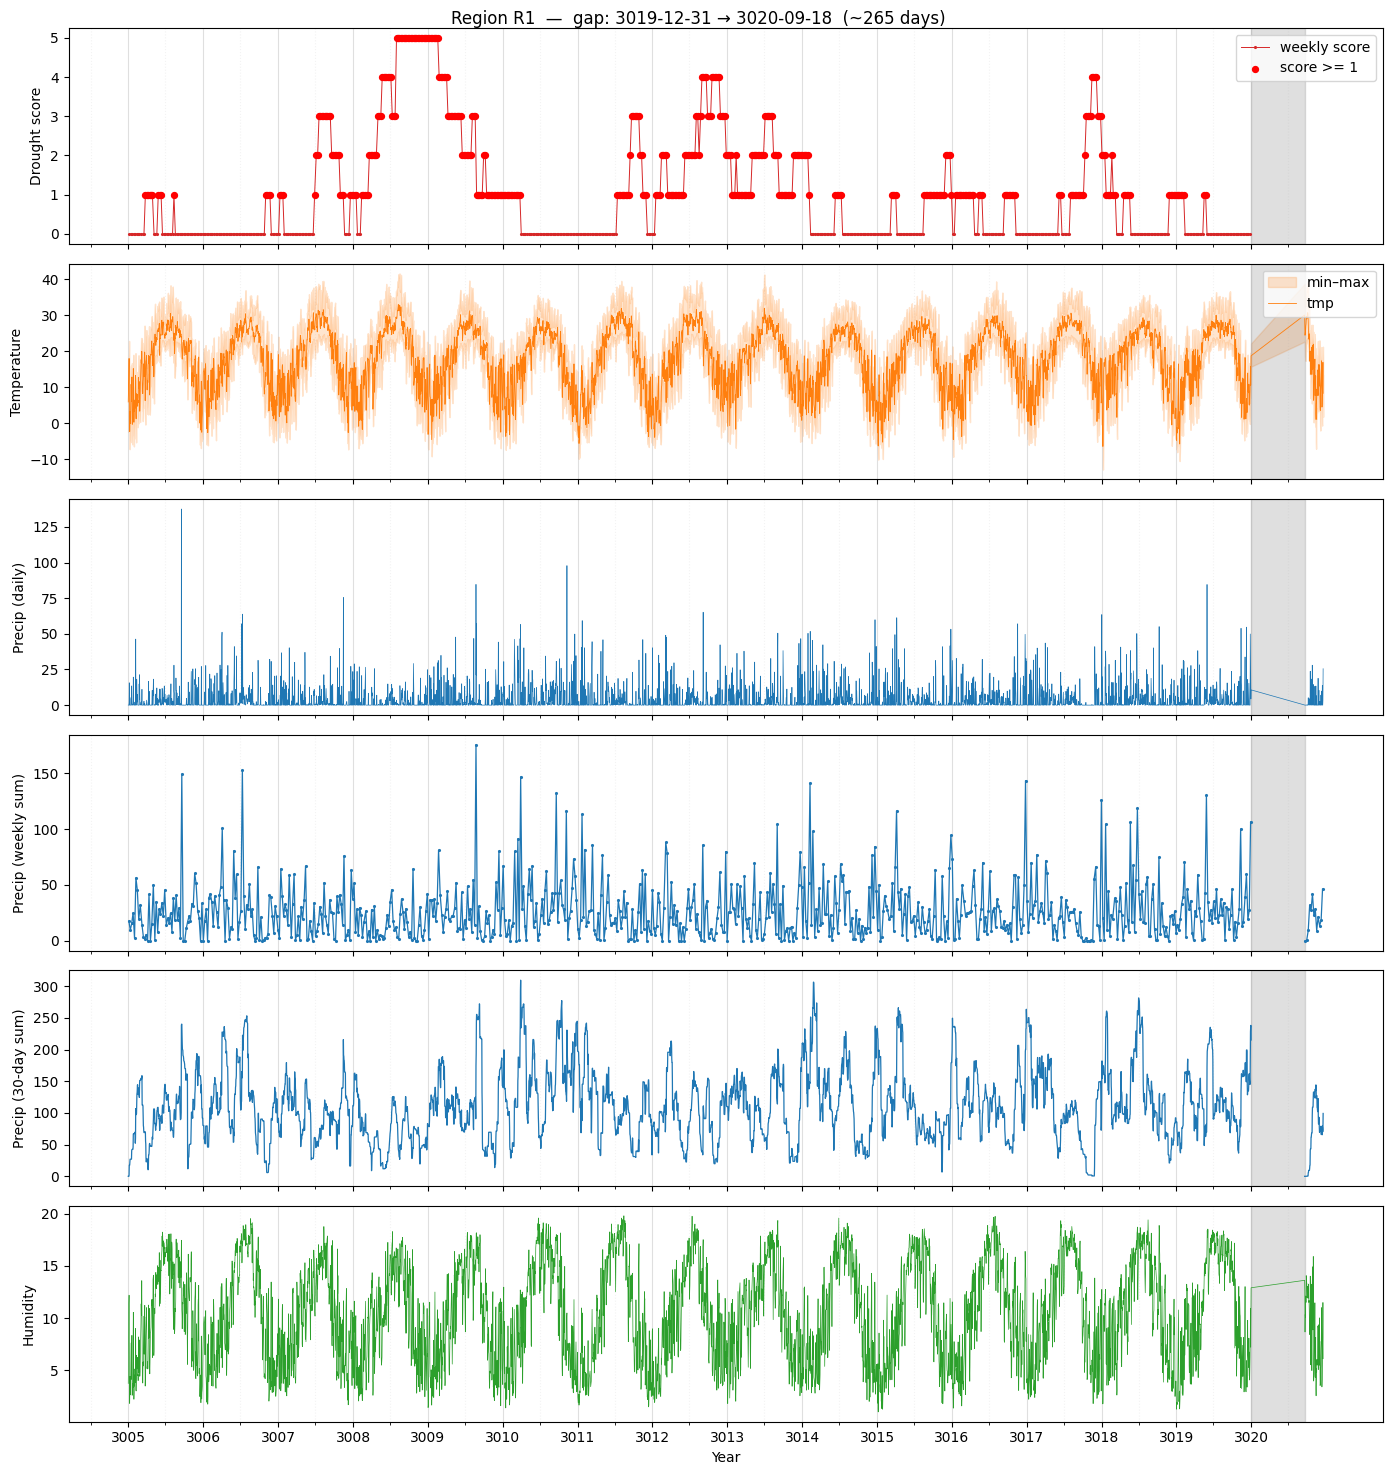

In [52]:
explore_region('R1')

In [ ]:
table_view('R1')